# Perceptron

This notebook implement a single perceptron in pyton learning a simple boolean operator

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

## Initialization

In [2]:
n_entries = 2  # Number of entries
n_values = 2  # Number of values # 0 or 1
epochs = 8  # Number of epochs
n = pow(n_values, n_entries)  # Size of the learning set

### Inputs
We'd like to learn this boolean function: $y = x_1 \land x_2$
|$x_1$ | $x_2$ | $y$ |
|------|-------|-----|
|$0$   |$0$    |$0$  |
|$0$   |$1$    |$0$  |
|$1$   |$0$    |$0$  |
|$1$   |$1$    |$1$  |

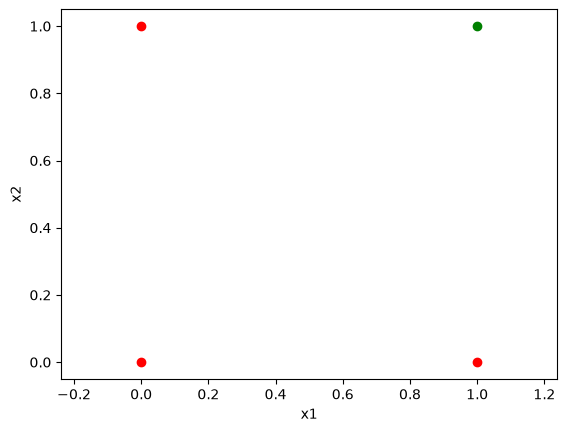

In [3]:
# Read the values of y for all examples p and q
epoch = 0
x1 = np.array([0, 0, 1, 1])
x2 = np.array([0, 1, 0, 1])
y = np.array([0, 0, 0, 1])
y2D = y.reshape(n_entries, n_entries)

# Plot the function to learn on a graph
for i in range(n_entries):
    for j in range(n_entries):
        plt.scatter(i, j, color="green" if y2D[i, j] else "red")

plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

### Learning algorithm of a perceptron

Having the boolean outputs, let's now apply the learning algorithm of a perceptron.

The formal neuron [McCulloch et Pitts, 1942] is the output $y$ defined by:  
$\small\displaystyle y = 
\begin{cases}
  1 & \text{if } \sum\limits_{i=1}^{n}w_ix_i > \theta \\
  0 & \text{otherwise}
\end{cases}$

where $\mathbf w = (w_1, w_2, \theta)$ are the weights with $\theta$ the threshold.

The algorithm of the perceptron [Rosenblatt, 1957] is looking for a hyperplane / decision boundary of equation $\small \mathbf{ ⟨w,x_i⟩} + \theta = 0$.  
It is an ancestor of the gradient descent:

```python
W := random()
for X in L:
  if Y * <W,X> < 0:
    W = W + Y * X
```
See also the formalism of a SVM Linear Classifier

Initial weights (w1, w2, theta):
[0.24, 0.17, 0.71]
************************************
Final weights (w1, w2, theta):
[2.24, 1.17, 2.71]
************************************
Equation of the line:
x2 = -1.91 * x1 + 2.32


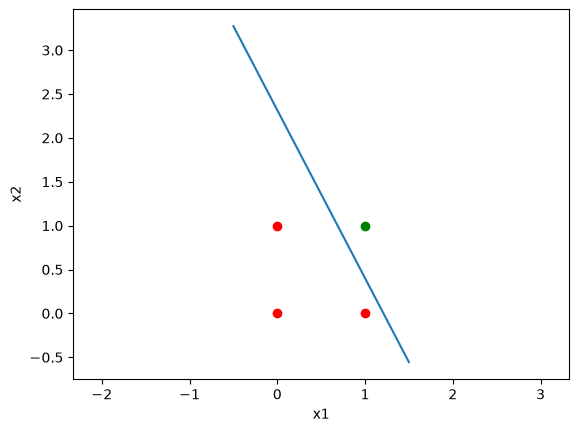

In [8]:
#  Initialization of weights w and traces of the weights w_t
w = [round(random.random(), 2) for i in range(n_entries + 1)]  # +1 for theta
print("Initial weights (w1, w2, theta):")
print(w)

sum_wx = 0

# Store the weights for each epoch and each example
w1_t = np.zeros(epochs * n)
w2_t = np.zeros(epochs * n)
w3_t = np.zeros(epochs * n)


# Learning process
s = 0
for epoch in range(epochs):
    for i in range(n):
        # Store the weights of the current epoch and example
        w1_t[s], w2_t[s], w3_t[s] = w[0], w[1], w[2]
        sum_wx = round(w[0] * x1[i] + w[1] * x2[i] - w[2], 2)
        if sum_wx >= 0 and y[i] != 1:  # SUB
            w[0] = w[0] - x1[i]
            w[1] = w[1] - x2[i]
            w[2] = w[2] + 1
        if sum_wx < 0 and y[i] == 1:  # ADD
            w[0] = w[0] + x1[i]
            w[1] = w[1] + x2[i]
            w[2] = w[2] - 1
        s = s + 1

for i in range(0, n_entries + 1):
    w[i] = float(round(w[i], 2))

print("************************************")
print("Final weights (w1, w2, theta):")
print(w)

# Avoid division by zero in the case of w[1] = 0 or w[0] = 0
if w[1] == 0:
    w[1] = 0.01
if w[0] == 0:
    w[0] = 0.01

a = -w[0] / w[1]
b = w[2] / w[1]

x = np.linspace(-0.5, 1.5, 2000)
l1 = a * x + b

print("************************************")
print("Equation of the line:")
print(f"x2 = {a:.2f} * x1 + {b:.2f}")

plt.figure()
plt.plot(x, l1)
plt.axis("equal")
plt.xlabel("x1")
plt.ylabel("x2")

for i in range(0, n_entries):
    for j in range(0, n_entries):
        plt.scatter(i, j, color="green" if y2D[i, j] else "red")

plt.show()

### Results

The perceptron has successfully learned the AND function. After 8 epochs, the final weights are:

- $w_1$ = 2.24
- $w_2$ = 1.17
- $\theta$ = 2.71

This gives the decision boundary:

$x_2 = -1.91 x_1 + 2.32$

The model predicts `True` only when on the left side of the boundary.

$w_1 x_1 + w_2 x_2 - \theta \geq 0 \iff 2.24x_1 + 1.17 w_2 \geq 2.32$ 

0: Sum=-2.71000 and y=0
1: Sum=-1.54000 and y=0
2: Sum=-0.47000 and y=0
3: Sum=0.70000 and y=1
Success of the learning process


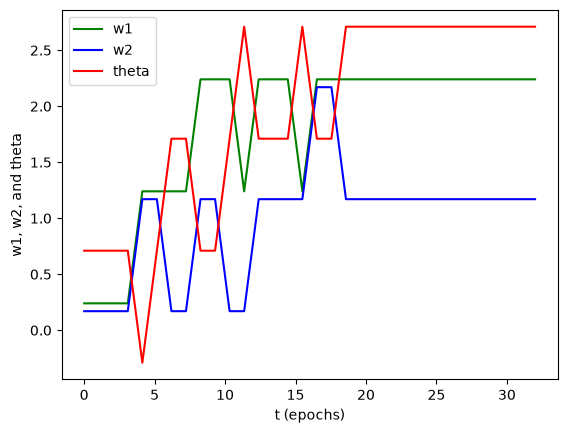

In [15]:
itsworking = True

for i in range(n):
    sum_wx = w[0] * x1[i] + w[1] * x2[i] - w[2]  # Calculate the weighted sum
    print(f"{i}: Sum={sum_wx:.5f} and y={y[i]}")
    if sum_wx >= 0 and y[i] == 0 or sum_wx < 0 and y[i] == 1:
        itsworking = False

print(f"Learning process {'successful' if itsworking else 'failed'}")

x = np.linspace(0, epochs * 4, epochs * 4)
plt.figure()
plt.plot(x, w1_t, "green", label="w1")
plt.plot(x, w2_t, "blue", label="w2")
plt.plot(x, w3_t, "red", label="theta")
plt.xlabel("t (epochs)")
plt.ylabel("w1, w2, and theta")
plt.legend()
plt.show()

We can observe the convergence of the weights after 19 iterations.